# 🦁 ZooVision AI: Automated Animal Classification
**Major Project: Transfer Learning with MobileNetV2**

### 1. Abstract
This notebook documents the enterprise-grade training pipeline for the ZooVision AI project. To overcome "Background Bias" (where naive models confuse habitats for subjects), we utilize **Transfer Learning**. We will import Google's highly optimized `MobileNetV2` architecture, freeze its core feature-extraction layers, and train a custom classification head on top of it to accurately identify 15 distinct animal species.

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow Version: {tf.__version__}")
# Set random seed for reproducibility
tf.random.set_seed(42)

TensorFlow Version: 2.21.0


### 2. Data Ingestion & Preprocessing
Because we are using Google's pre-trained brain, we must format our images using Google's exact mathematical formula (mapping pixel values to between -1.0 and 1.0) rather than a standard 0-to-1 normalization. We also apply Data Augmentation to prevent overfitting.

In [6]:
# Define paths and hyperparameters
DATA_DIR = './data' # Ensure your animal folders are inside a 'data' folder
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# 1. Data Augmentation Generator with MobileNetV2 Preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input, # The Magic Fix!
    rotation_range=20,        
    zoom_range=0.2,           
    horizontal_flip=True,     
    validation_split=0.2      
)

# 2. Load Training Data
print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# 3. Load Validation Data
print("\nLoading Validation Data:")
val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False # Do not shuffle validation data for accurate evaluation!
)

# Save class names for later
class_names = list(train_generator.class_indices.keys())
print(f"\nDetected Classes ({len(class_names)}): {class_names}")

Loading Training Data:
Found 1561 images belonging to 15 classes.

Loading Validation Data:
Found 383 images belonging to 15 classes.

Detected Classes (15): ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']


### 3. Neural Network Architecture Definition (Transfer Learning)
We instantiate the `MobileNetV2` model pre-trained on the ImageNet dataset. We chop off its final layer (`include_top=False`) and freeze its weights. We then attach a `GlobalAveragePooling2D` layer to compress the features, followed by a `Dense` softmax layer to map the features to our 15 specific animals.

In [7]:
num_classes = len(class_names)

# 1. Load Google's Pre-trained Brain
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False, 
    weights='imagenet' 
)

# 2. Freeze the brain so we don't accidentally erase its memories
base_model.trainable = False

# 3. Attach our custom classification layers to the top
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.2), # 20% Dropout to prevent overfitting
    Dense(num_classes, activation='softmax') # Outputs probability distribution
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 4. Model Training & Early Stopping
We will train the custom head for 15 epochs. We utilize the `EarlyStopping` callback to automatically halt training if the validation loss stops improving, ensuring we capture the model at its absolute peak performance.

In [8]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 55s 991ms/step - accuracy: 0.5227 - loss: 1.6161 - val_accuracy: 0.8433 - val_loss: 0.7013
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 46s 934ms/step - accuracy: 0.8751 - loss: 0.5125 - val_accuracy: 0.8982 - val_loss: 0.4398
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 46s 930ms/step - accuracy: 0.9263 - loss: 0.3243 - val_accuracy: 0.9112 - val_loss: 0.3683
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 923ms/step - accuracy: 0.9334 - loss: 0.2636 - val_accuracy: 0.9138 - val_loss: 0.3425
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 923ms/step - accuracy: 0.9481 - loss: 0.2023 - val_accuracy: 0.9347 - val_loss: 0.2733
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 911ms/step - accuracy: 0.9564 - loss: 0.1673 - val_accuracy: 0.9191 - val_loss: 0.2882
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 46s 943ms/step - accuracy: 0.9558 - loss: 0.1562 - val_accuracy: 0.9164 - val_loss: 0.2713
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 911ms/step - accuracy: 0.9648 - loss: 0.1363 - val_accu

### 5. Performance Evaluation & Visualization
We visualize the learning curves to check for convergence and plot a Confusion Matrix to see exactly how well the model distinguishes between visually similar species (e.g., Leopard vs. Tiger).

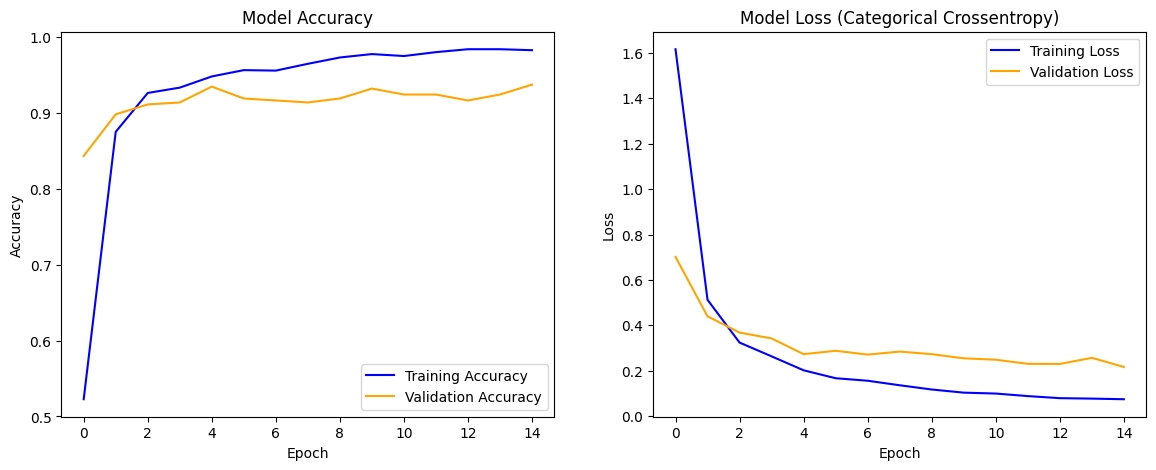

Generating Predictions for Confusion Matrix...
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 857ms/step


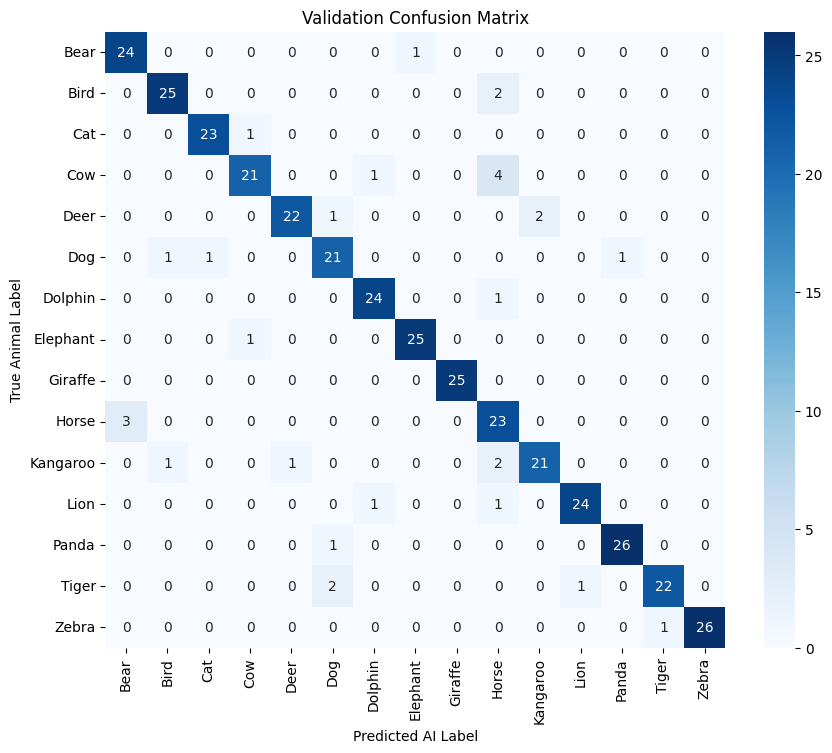


Classification Report:
              precision    recall  f1-score   support

        Bear       0.89      0.96      0.92        25
        Bird       0.93      0.93      0.93        27
         Cat       0.96      0.96      0.96        24
         Cow       0.91      0.81      0.86        26
        Deer       0.96      0.88      0.92        25
         Dog       0.84      0.88      0.86        24
     Dolphin       0.92      0.96      0.94        25
    Elephant       0.96      0.96      0.96        26
     Giraffe       1.00      1.00      1.00        25
       Horse       0.70      0.88      0.78        26
    Kangaroo       0.91      0.84      0.88        25
        Lion       0.96      0.92      0.94        26
       Panda       0.96      0.96      0.96        27
       Tiger       0.96      0.88      0.92        25
       Zebra       1.00      0.96      0.98        27

    accuracy                           0.92       383
   macro avg       0.92      0.92      0.92       383
we

In [9]:
# 1. Plot Accuracy & Loss
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Loss Plot
ax[1].plot(history.history['loss'], label='Training Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax[1].set_title('Model Loss (Categorical Crossentropy)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.show()

# 2. Confusion Matrix
print("Generating Predictions for Confusion Matrix...")
val_generator.reset()
predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted AI Label')
plt.ylabel('True Animal Label')
plt.show()

# 3. Classification Report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

### 6. Artifact Serialization (TFLite Conversion)
To deploy this highly accurate model to a web browser, we must compress it from a massive TensorFlow saved model into a lightweight `.tflite` mobile format.

In [10]:
# Save original Keras model
model.save('animal_classifier.keras')
print("✅ Full Keras model saved.")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('animal_classifier.tflite', 'wb') as f:
    f.write(tflite_model)
    
print("✅ Compressed TFLite model saved successfully. Ready for deployment!")

✅ Full Keras model saved.
INFO:tensorflow:Assets written to: C:\Users\KAMALP~1\AppData\Local\Temp\tmp1o9gub4p\assets


INFO:tensorflow:Assets written to: C:\Users\KAMALP~1\AppData\Local\Temp\tmp1o9gub4p\assets


Saved artifact at 'C:\Users\KAMALP~1\AppData\Local\Temp\tmp1o9gub4p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_308')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  1905801293904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906907397968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906846264272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906846264848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906907397776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906846263504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906908087888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906908088080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906908087312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906908086736: TensorSpec(shape=(), dtype=tf.resource, name=None)